
# 🌸 Flower Classification using MobileNetV2 

This notebook walks through the process of using **transfer learning** with **MobileNetV2** for flower species classification using TensorFlow.

---

## ✅ Step 1: Install Required Libraries



---

## ✅ Step 2: Folder Structure
Ensure your folder contains:
```
project_folder/
├── flower_classifier_mobilenet.ipynb
└── flowers/
    ├── daisy/
    ├── dandelion/
    ├── rose/
    ├── sunflower/
    └── tulip/
```

---


---

## Step-3 :Steps followed :
- Load & preprocess image data
- Load MobileNetV2 (pretrained on ImageNet)
- Fine-tune the model with frozen base
- Train and evaluate with accuracy, precision, recall, F1-score
- Visualize confusion matrix
- Save the model

---

Happy Training! 🌻🌹🌼🌷🌸


# Flower Classification using Transfer Learning (MobileNet & ResNet)

This notebook fine-tunes MobileNetV2 in TensorFlow and ResNet18 in PyTorch to classify 5 flower species.

In [1]:
!pip install tensorflow scikit-learn matplotlib seaborn


[notice] A new release of pip is available: 24.2 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Step 1: Import Required Libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [3]:
# Step 2: Set Data Paths (Update this path if needed)
data_dir = "flowers"  # Assumes flowers folder is in the same directory
img_height, img_width = 224, 224
batch_size = 32

In [4]:
# Step 3: Preprocess Data and Split (75/25)
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.25)

train_data = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    subset='training',
    class_mode='categorical')

val_data = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    subset='validation',
    class_mode='categorical')

Found 3238 images belonging to 5 classes.
Found 1079 images belonging to 5 classes.


In [5]:
# Step 4: Load MobileNetV2 with Pretrained Weights
base_model = MobileNetV2(input_shape=(img_height, img_width, 3),
                         include_top=False,
                         weights='imagenet')
base_model.trainable = False  # Freeze base layers

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(5, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
# Step 5: Train the Model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

C:\Users\satya\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 92s 754ms/step - accuracy: 0.6700 - loss: 0.8782 - val_accuracy: 0.8526 - val_loss: 0.4140
Epoch 2/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 75s 733ms/step - accuracy: 0.8861 - loss: 0.3383 - val_accuracy: 0.8638 - val_loss: 0.3924
Epoch 3/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 74s 727ms/step - accuracy: 0.9119 - loss: 0.2549 - val_accuracy: 0.8656 - val_loss: 0.3965
Epoch 4/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 80s 709ms/step - accuracy: 0.9334 - loss: 0.1914 - val_accuracy: 0.8601 - val_loss: 0.3956
Epoch 5/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 75s 732ms/step - accuracy: 0.9541 - loss: 0.1504 - val_accuracy: 0.8675 - val_loss: 0.3813
Epoch 6/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 90s 879ms/step - accuracy: 0.9675 - loss: 0.1077 - val_accuracy: 0.8638 - val_loss: 0.4285
Epoch 7/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 78s 761ms/step - accuracy: 0.9603 - loss: 0.1083 - val_accuracy: 0.8656 - val_loss: 0.4347
Epoch 8/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 75s 731ms/step - accuracy: 0.9804 - loss: 0

34/34 ━━━━━━━━━━━━━━━━━━━━ 27s 688ms/step
              precision    recall  f1-score   support

       daisy       0.17      0.18      0.18       191
   dandelion       0.25      0.25      0.25       263
        rose       0.15      0.14      0.15       196
   sunflower       0.17      0.15      0.16       183
       tulip       0.22      0.23      0.22       246

    accuracy                           0.20      1079
   macro avg       0.19      0.19      0.19      1079
weighted avg       0.20      0.20      0.20      1079



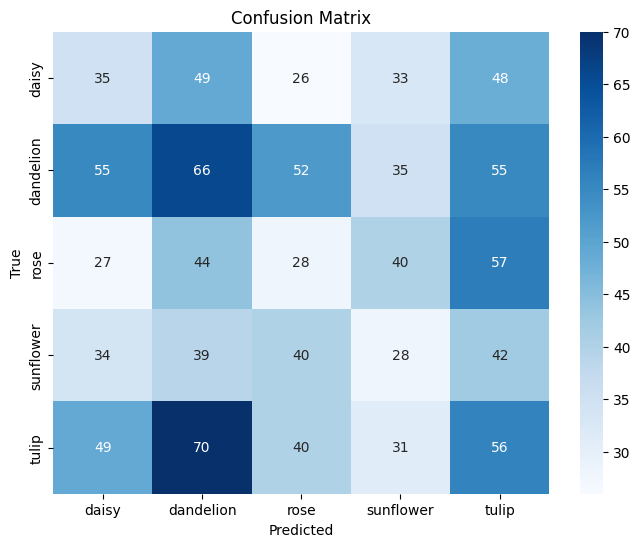

In [7]:
# Step 6: Evaluate the Model
val_data.reset()
preds = model.predict(val_data)
y_pred = np.argmax(preds, axis=1)
y_true = val_data.classes

# Classification Report
print(classification_report(y_true, y_pred, target_names=val_data.class_indices.keys()))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=val_data.class_indices.keys(), yticklabels=val_data.class_indices.keys(), cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Optional: Save Model
model.save('mobilenet_flower_classifier.h5')

##  PyTorch Implementation: Transfer Learning with ResNet18
In this section, we replicate the flower classification using PyTorch and ResNet18.

In [9]:
!pip install torch

   ---------------------------------------- 0.0/212.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/212.5 MB ? eta -:--:--
   ---------------------------------------- 1.3/212.5 MB 4.0 MB/s eta 0:00:54
   ---------------------------------------- 2.1/212.5 MB 4.2 MB/s eta 0:00:51
    --------------------------------------- 3.1/212.5 MB 4.5 MB/s eta 0:00:47
    --------------------------------------- 4.2/212.5 MB 4.7 MB/s eta 0:00:45
    --------------------------------------- 4.7/212.5 MB 4.3 MB/s eta 0:00:49
   - -------------------------------------- 5.8/212.5 MB 4.2 MB/s eta 0:00:49
   - -------------------------------------- 6.3/212.5 MB 4.1 MB/s eta 0:00:50
   - -------------------------------------- 6.3/212.5 MB 4.1 MB/s eta 0:00:50
   - -------------------------------------- 6.3/212.5 MB 4.1 MB/s eta 0:00:50
   - -------------------------------------- 6.8/212.5 MB 3.2 MB/s eta 0:01:06
   - -------------------------------------- 7.1/212.5 MB 3.0 MB/s eta 0:01:09



[notice] A new release of pip is available: 24.2 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   -------- ------------------------------- 43.8/212.5 MB 1.8 MB/s eta 0:01:36
   -------- ------------------------------- 44.0/212.5 MB 1.7 MB/s eta 0:01:37
   -------- ------------------------------- 44.0/212.5 MB 1.7 MB/s eta 0:01:37
   -------- ------------------------------- 44.3/212.5 MB 1.7 MB/s eta 0:01:37
   -------- ------------------------------- 44.6/212.5 MB 1.7 MB/s eta 0:01:38
   -------- ------------------------------- 44.8/212.5 MB 1.7 MB/s eta 0:01:38
   -------- ------------------------------- 45.1/212.5 MB 1.7 MB/s eta 0:01:38
   -------- ------------------------------- 45.1/212.5 MB 1.7 MB/s eta 0:01:38
   -------- ------------------------------- 45.6/212.5 MB 1.7 MB/s eta 0:01:38
   -------- ------------------------------- 45.9/212.5 MB 1.7 MB/s eta 0:01:38
   -------- ------------------------------- 45.9/212.5 MB 1.7 MB/s eta 0:01:38
   -------- ------------------------------- 46.1/212.5 MB 1.7 MB/s eta 0:01:39
   -------- ------------------------------- 46.4/212

In [11]:
!pip install torchvision

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 1.1 MB/s eta 0:00:02
   ------------------------ --------------- 1.0/1.7 MB 1.3 MB/s eta 0:00:01
   ------------------------------ --------- 1.3/1.7 MB 1.4 MB/s eta 0:00:01
   ------------------------------------ --- 1.6/1.7 MB 1.3 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 1.3 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.2 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
# Step 1: Import Required Libraries for PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [14]:
# Step 2: Define Transforms and Data Loaders
data_dir = "flowers"
batch_size = 32
img_size = 224

transform = {
    'train': transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ]),
    'val': transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])
}

train_dataset = datasets.ImageFolder(root=os.path.join(data_dir), transform=transform['train'])
val_dataset = datasets.ImageFolder(root=os.path.join(data_dir), transform=transform['val'])

# Manual split 75/25
train_size = int(0.75 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [15]:
# Step 3: Load Pre-trained ResNet18 and Modify Final Layer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)
for param in model.parameters():
    param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 5)
)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

C:\Users\satya\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\satya\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\satya/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|█████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:22<00:00, 2.05MB/s]


In [19]:
# Step 4: Train the PyTorch Model
epochs = 5
model.train()

for epoch in range(epochs):
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

Epoch 1/5, Loss: 0.3028
Epoch 2/5, Loss: 0.2916
Epoch 3/5, Loss: 0.3026
Epoch 4/5, Loss: 0.2497
Epoch 5/5, Loss: 0.2567


              precision    recall  f1-score   support

           0       0.95      0.83      0.89       187
           1       0.90      0.94      0.92       255
           2       0.82      0.89      0.86       205
           3       0.90      0.90      0.90       177
           4       0.88      0.86      0.87       256

    accuracy                           0.89      1080
   macro avg       0.89      0.89      0.89      1080
weighted avg       0.89      0.89      0.89      1080



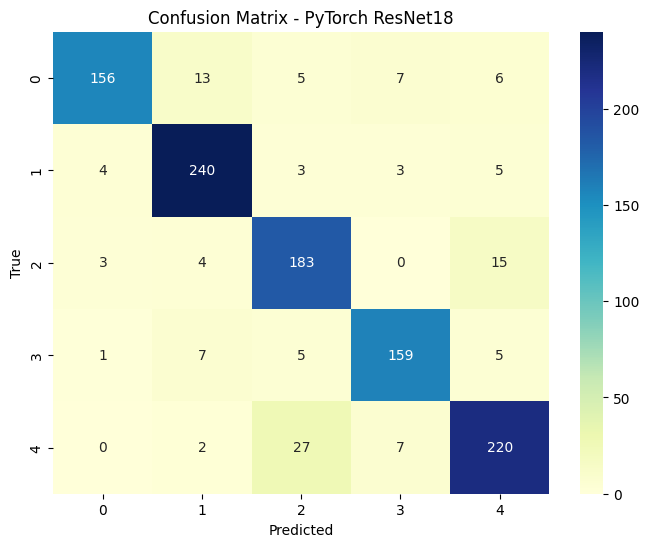

In [20]:
# Step 5: Evaluate PyTorch Model
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

# Classification Report
print(classification_report(y_true, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - PyTorch ResNet18")
plt.show()